In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_csv(r'C:\mydata\G8Vitamin\data\duy\raw_final.csv')
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30065 entries, 0 to 30064
Data columns (total 34 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   SEQN                      30065 non-null  float64
 1   Gender                    30065 non-null  float64
 2   Age                       30065 non-null  float64
 3   Race                      30065 non-null  float64
 4   PIR                       27524 non-null  float64
 5   Weight                    29603 non-null  float64
 6   Height                    29635 non-null  float64
 7   BMI                       29511 non-null  float64
 8   WaistCircumference        28600 non-null  float64
 9   Hba1c                     28397 non-null  float64
 10  FastingGlucose            28302 non-null  float64
 11  Albumin                   27953 non-null  float64
 12  ALT                       27923 non-null  float64
 13  AST                       27912 non-null  float64
 14  Alkali

In [3]:
# Get list of columns is category 
list_columns_category = ['Gender', 'Race', 'milk_consumption', 'label']

# List columns that not use
list_columns_unuse = ['SEQN', 'VitaminD', 'YearID']

In [4]:
# Create label for vitamin D level
df_raw['label'] = df_raw['VitaminD'].apply(
    lambda x: 1 if x < 50 else 0
)

In [5]:
# Draw countplot 
def draw_countplot(column, df):
    plt.figure(figsize=(10, 5))
    ax = sns.countplot(x=column, data=df, palette='viridis')
    
    plt.title(f'Distribution of {column}')
    for i, rec in enumerate(ax.patches):
        ax.text(
            rec.get_x() + rec.get_width()/2,
            rec.get_height() + 100,
            f'{rec.get_height()/len(df)*100:.2f}%',
            ha='center'
        )
    plt.show()

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_12836\4048447775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


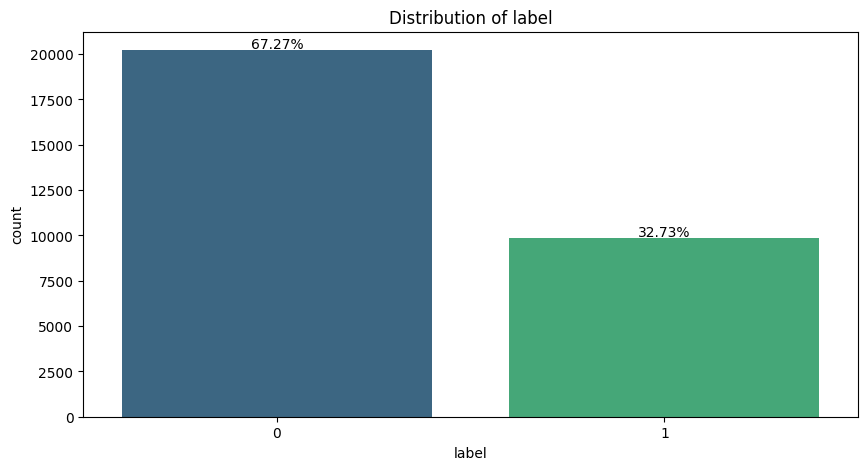

In [6]:
# Draw label distribution
draw_countplot('label', df_raw)

In [7]:
def draw_scatter_plot(x_name, y_name, df):
    sns.regplot(x=x_name, y=y_name, data=df, scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
    plt.title(f'{y_name} vs {x_name}')
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.grid(True)
    plt.show()

def draw_box_plot(x_name, y_name, df):
    sns.boxplot(x=x_name, y=y_name, data=df)
    plt.title(f'Phân bố {y_name} theo {x_name}')
    plt.xlabel(x_name)
    plt.ylabel(y_name)
    plt.grid(True)
    plt.show()

def draw_histogram_box_plot(column_name, df):
    # Get value min and max for column
    min_value = df[column_name].min()
    max_value = df[column_name].max()

    fig, ax = plt.subplots(figsize=(10, 5), nrows=1, ncols=2)

    # 1. Histogram with min and max lines
    sns.histplot(df[column_name].dropna(), bins=30, kde=True, ax=ax[0], color='skyblue')

    ax[0].axvline(min_value, color='red', linestyle='dashed', linewidth=1, label=f'Min: {min_value:.2f}')
    ax[0].axvline(max_value, color='green', linestyle='dashed', linewidth=1, label=f'Max: {max_value:.2f}')

    # ax[0].text(min_value, ax[0].get_ylim()[1] * 0.9, f'Min: {min_value:.2f}', color='red', ha='right', va='top')
    # ax[0].text(max_value, ax[0].get_ylim()[1] * 0.9, f'Max: {max_value:.2f}', color='green', ha='left', va='top')

    ax[0].set_title(f'Histogram of {column_name}')
    ax[0].set_xlabel(column_name)
    ax[0].set_ylabel('Frequency')
    ax[0].legend()

    # 2. Box plot
    sns.boxplot(x=df[column_name], ax=ax[1], color='lightgreen')
    ax[1].set_title(f'Box Plot of {column_name}')
    ax[1].set_xlabel(column_name)
    ax[1].set_ylabel('Value')

    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()


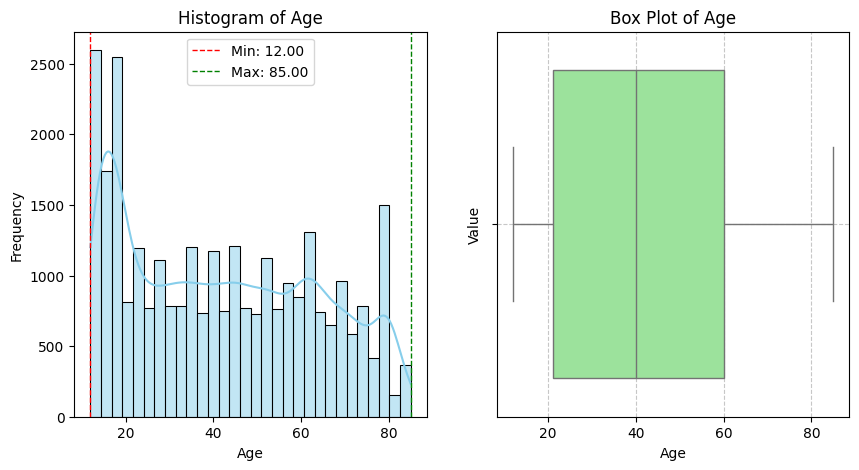

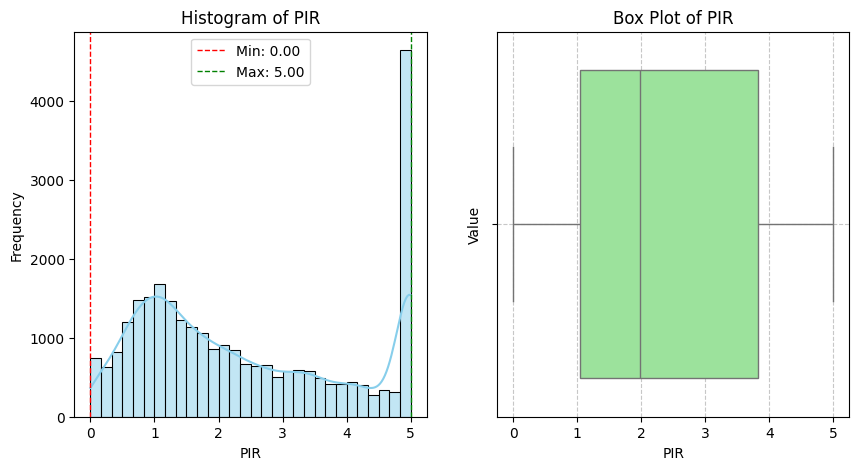

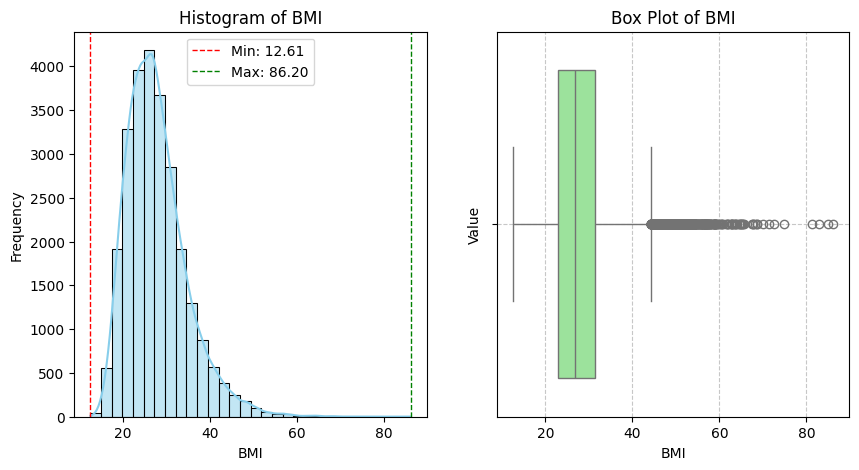

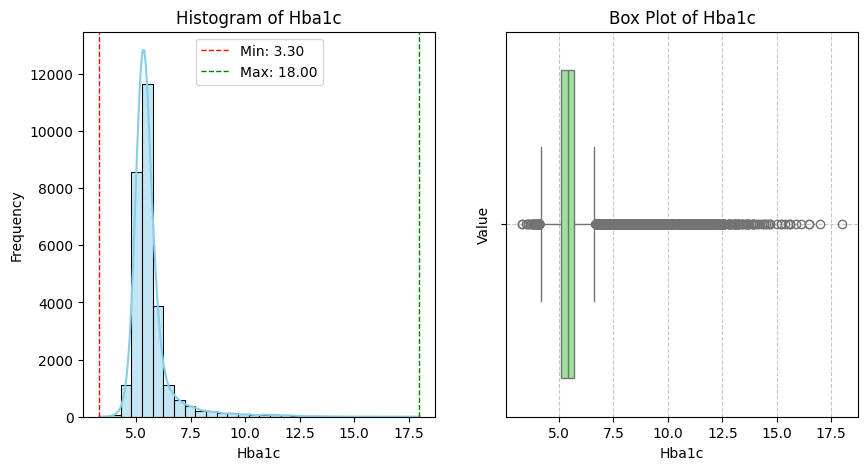

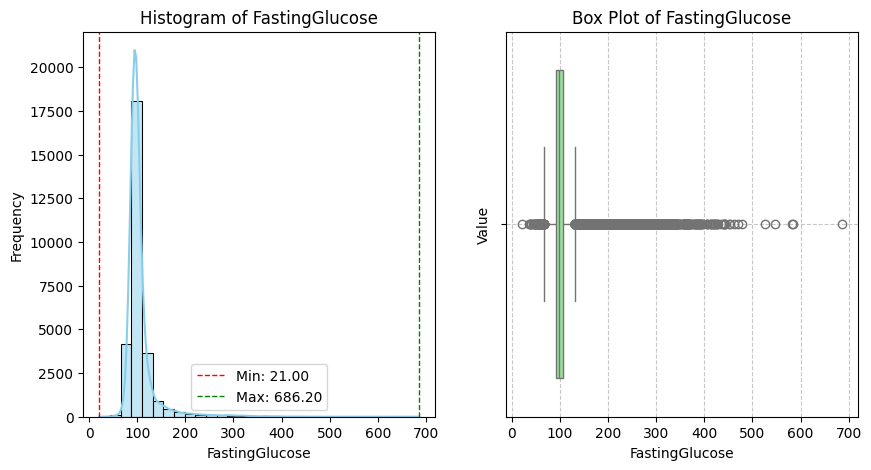

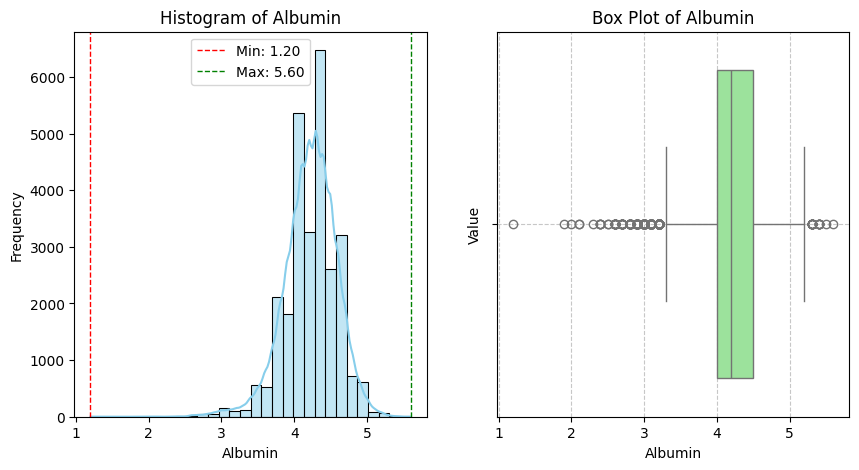

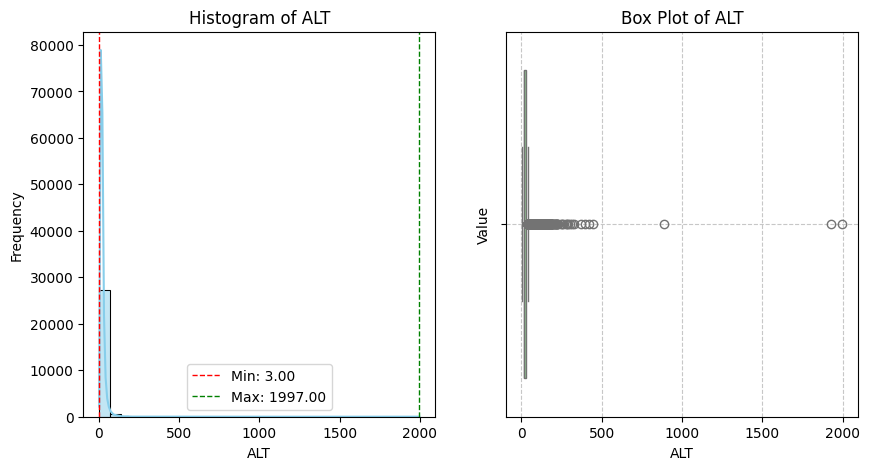

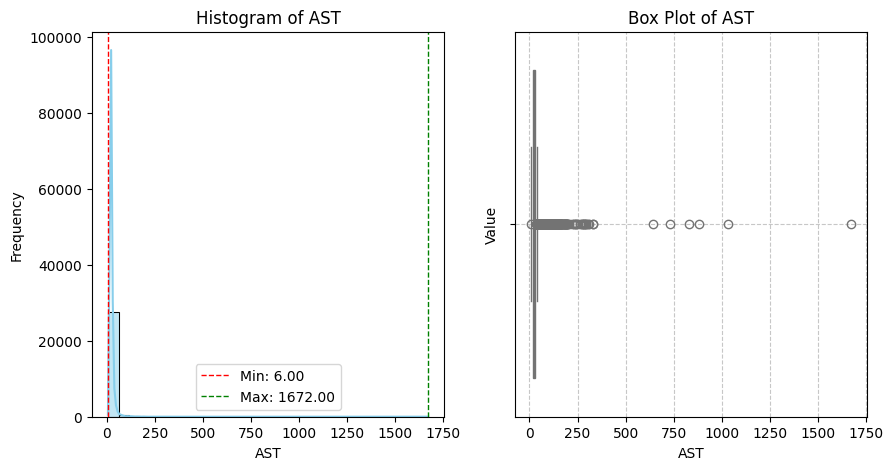

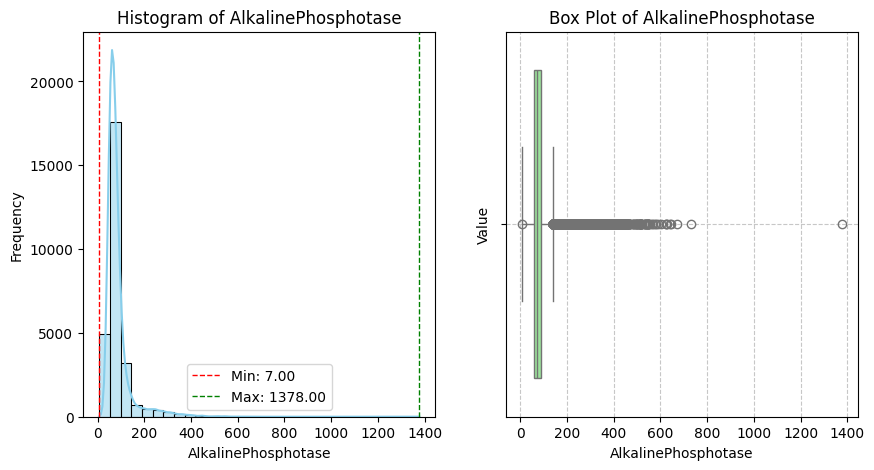

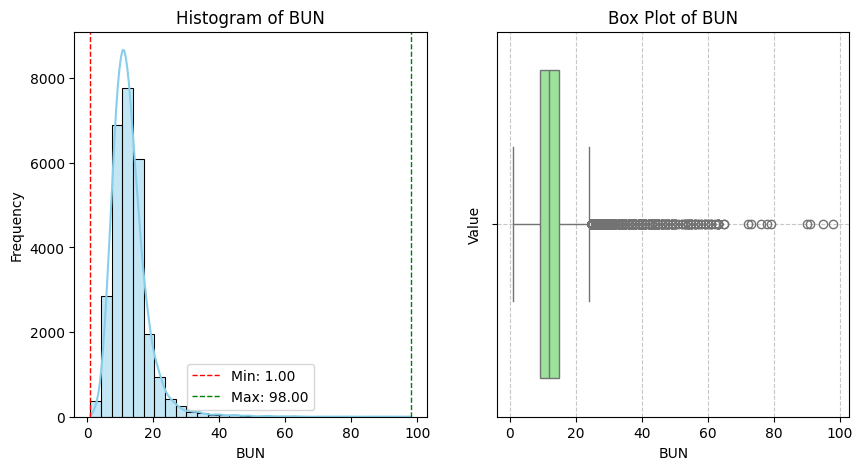

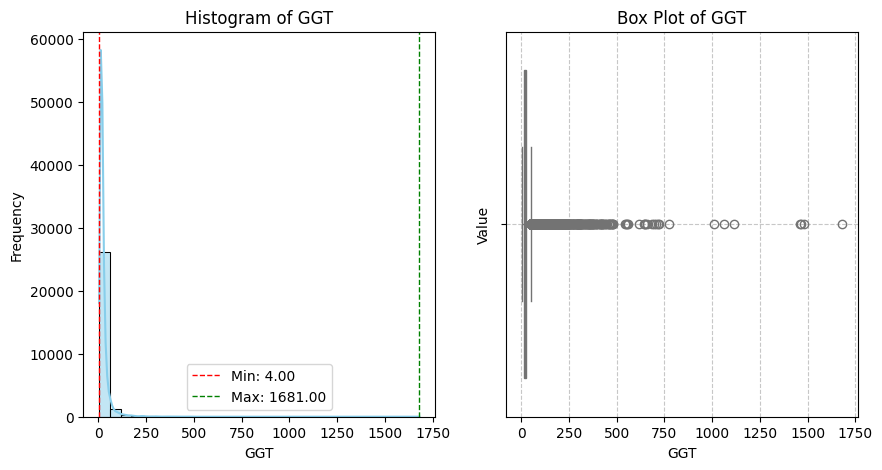

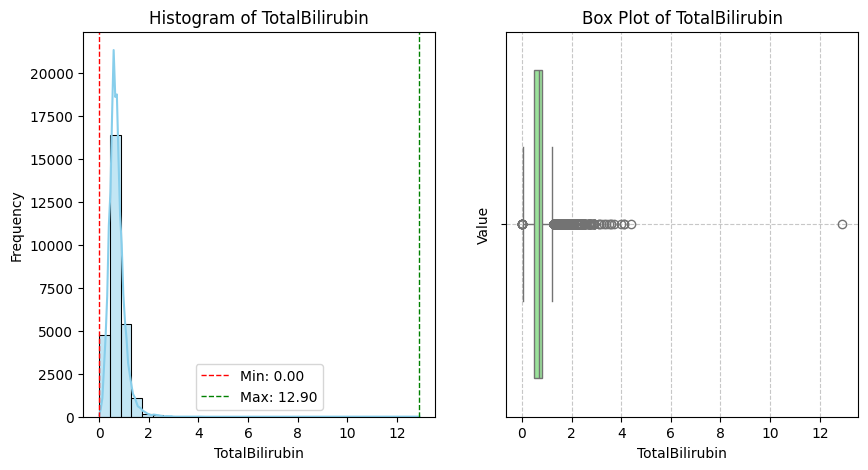

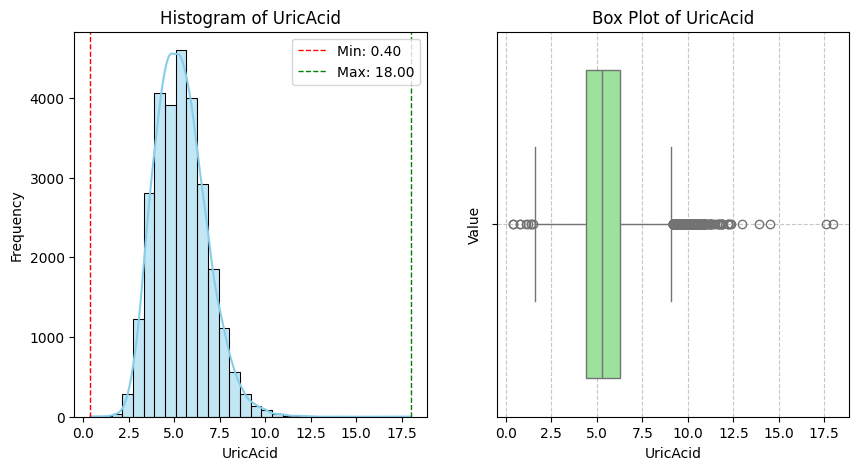

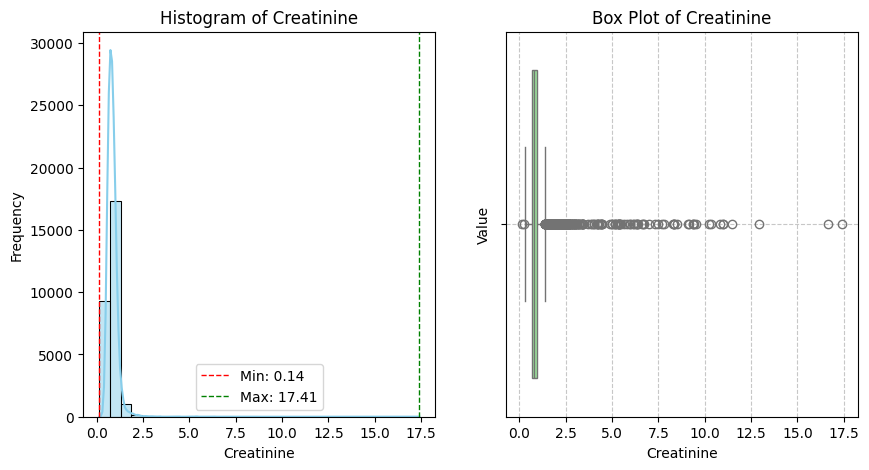

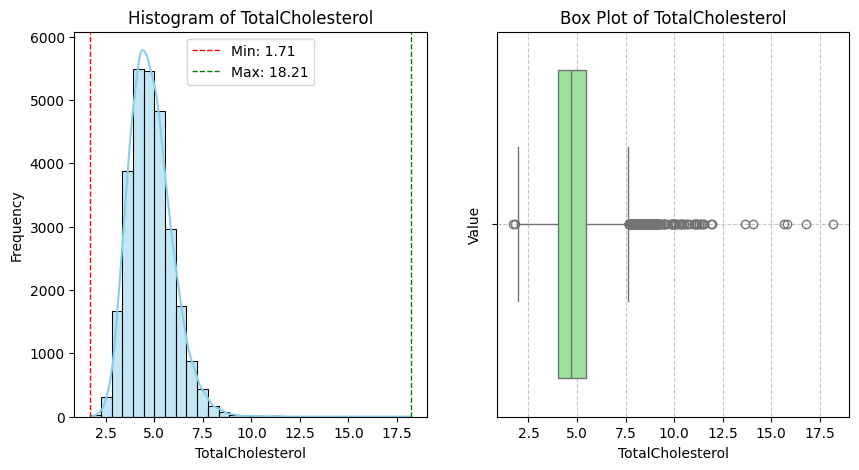

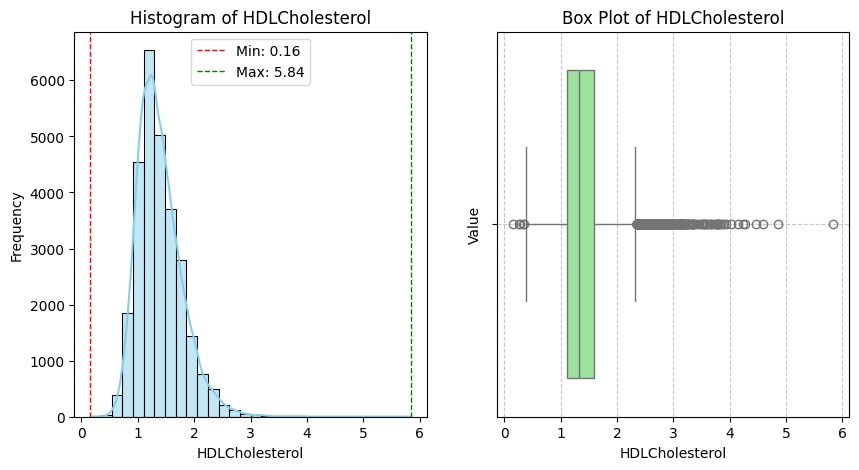

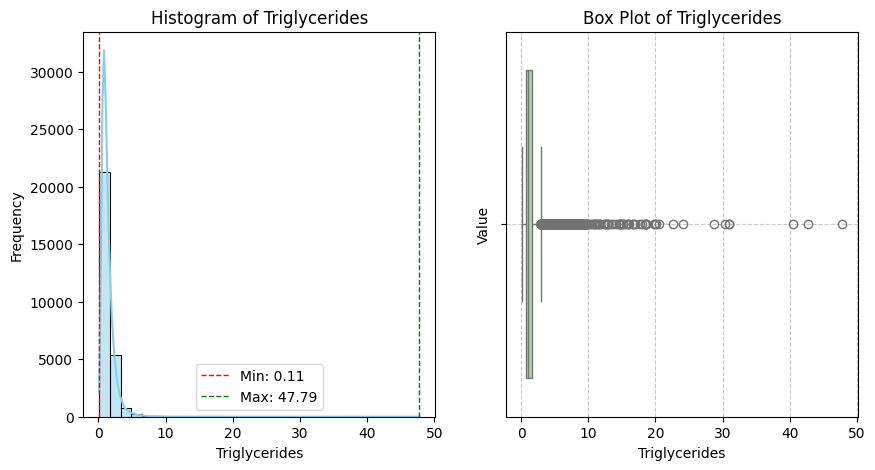

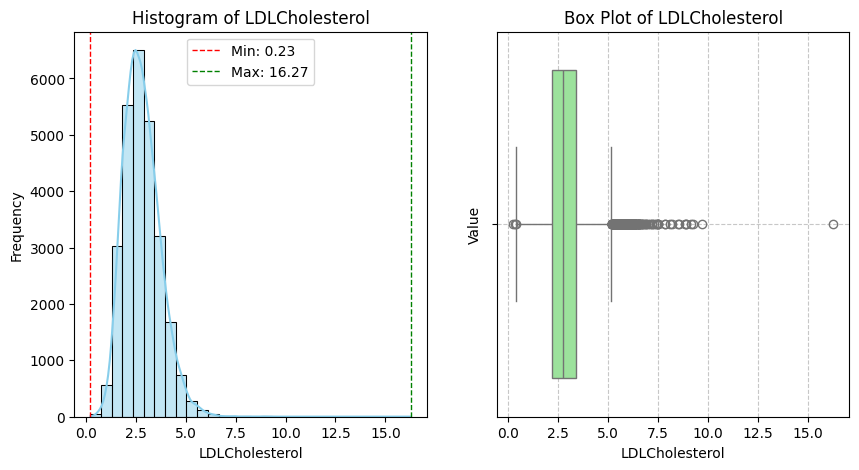

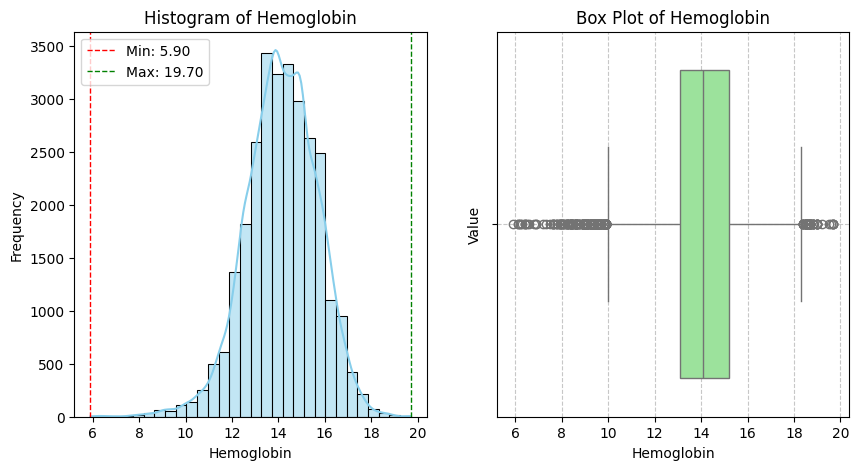

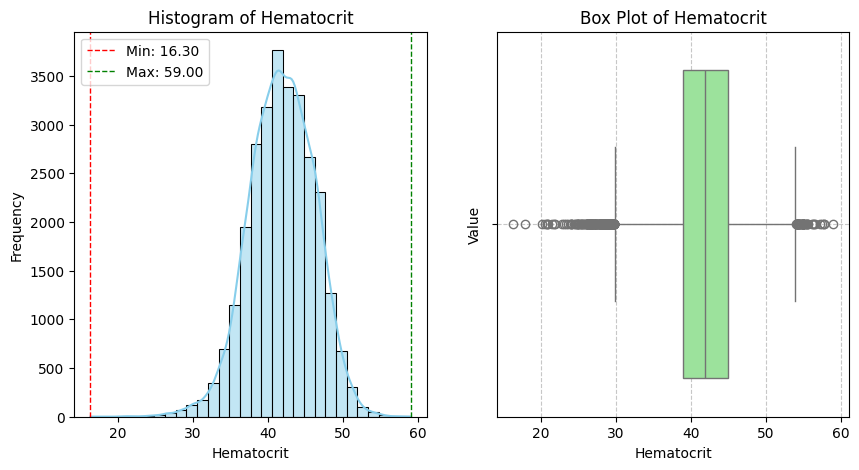

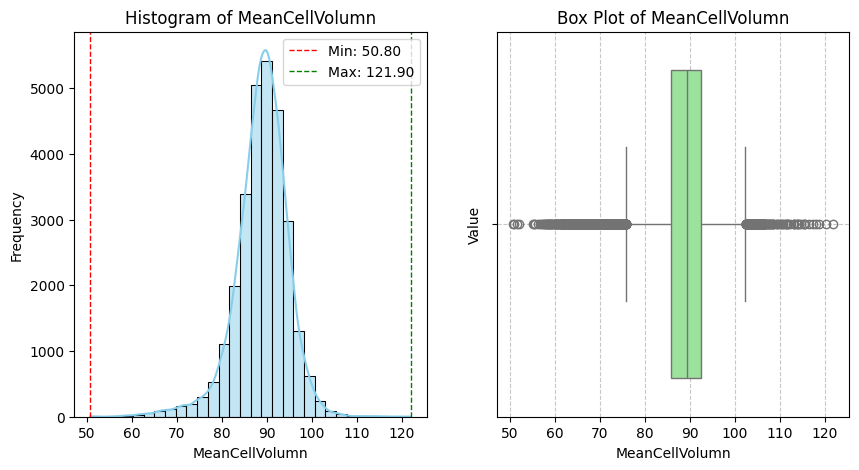

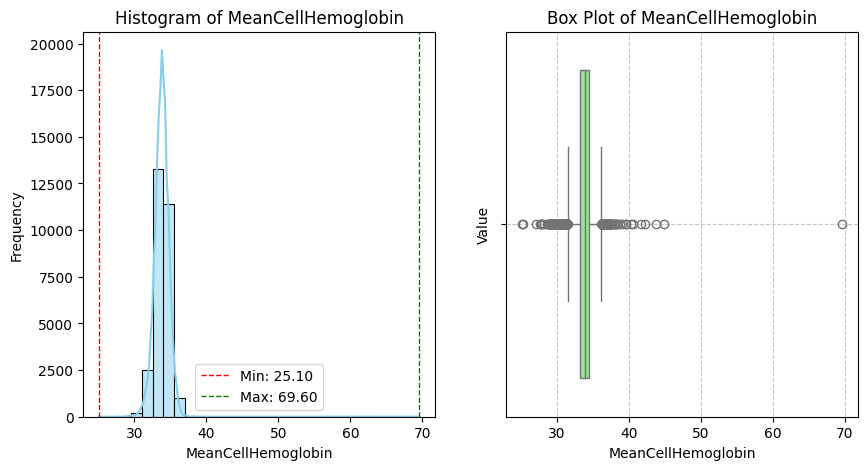

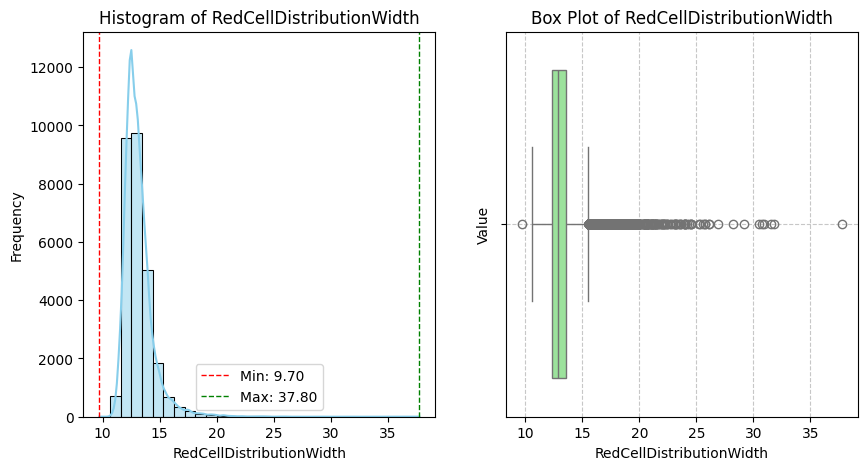

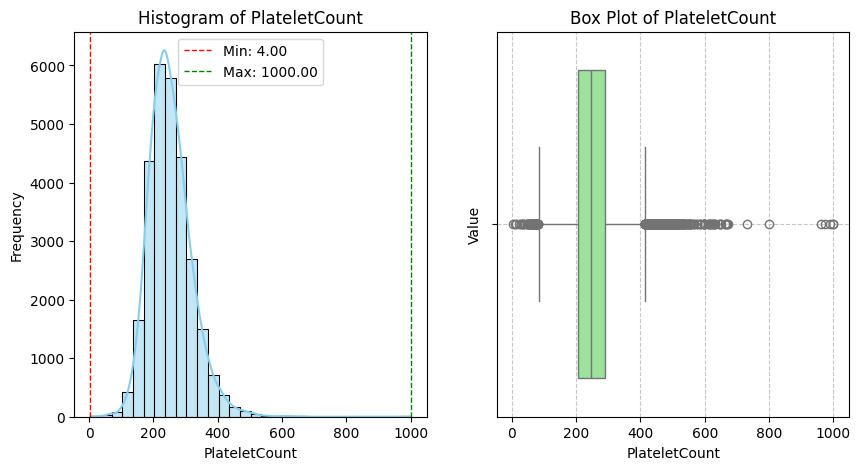

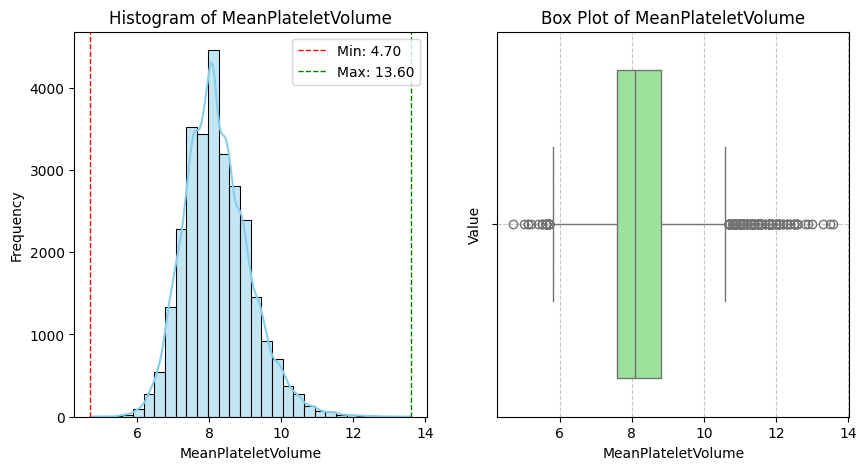

In [29]:
# Draw histogram and box plot for each numerical column
for col in df_raw.columns:
    if col not in list_columns_category and col not in list_columns_unuse:
        draw_histogram_box_plot(col, df_raw)

C:\Users\duyp6\AppData\Local\Temp\ipykernel_22088\4048447775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


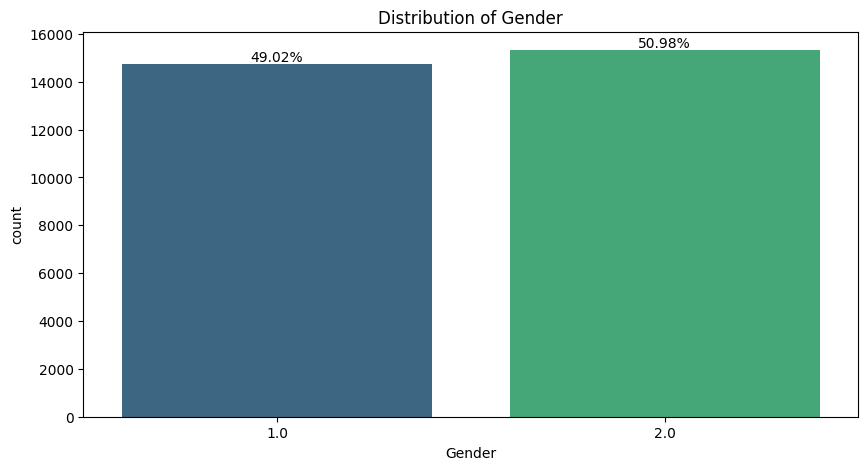

C:\Users\duyp6\AppData\Local\Temp\ipykernel_22088\4048447775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


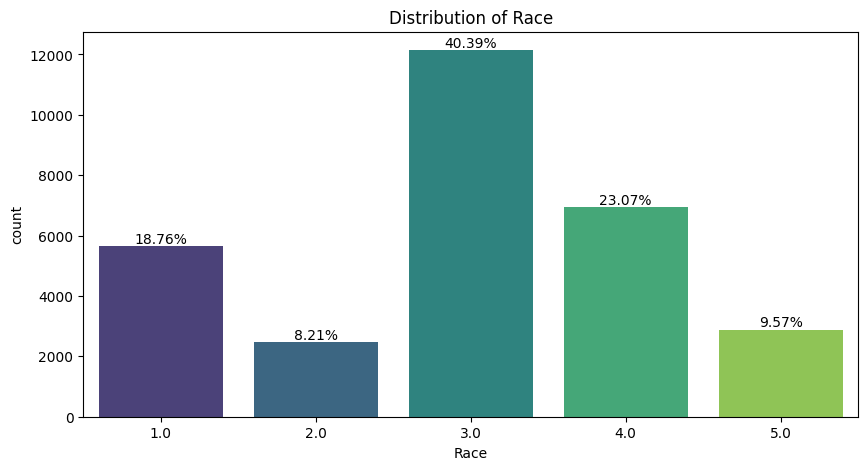

C:\Users\duyp6\AppData\Local\Temp\ipykernel_22088\4048447775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


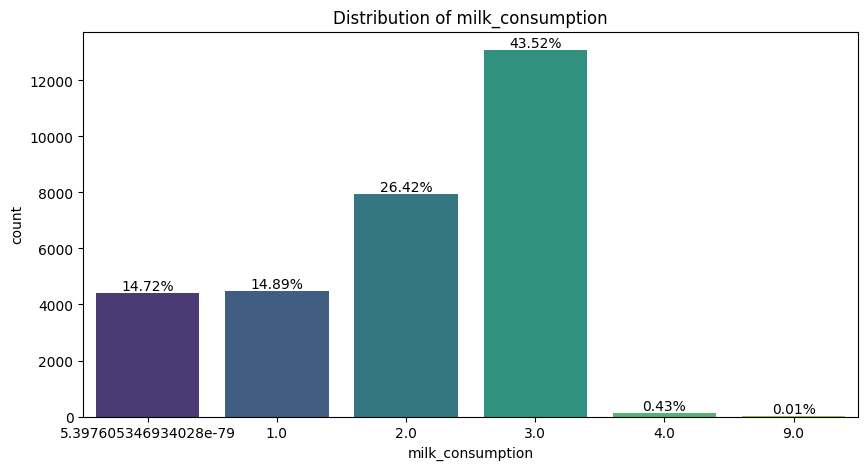

C:\Users\duyp6\AppData\Local\Temp\ipykernel_22088\4048447775.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x=column, data=df, palette='viridis')


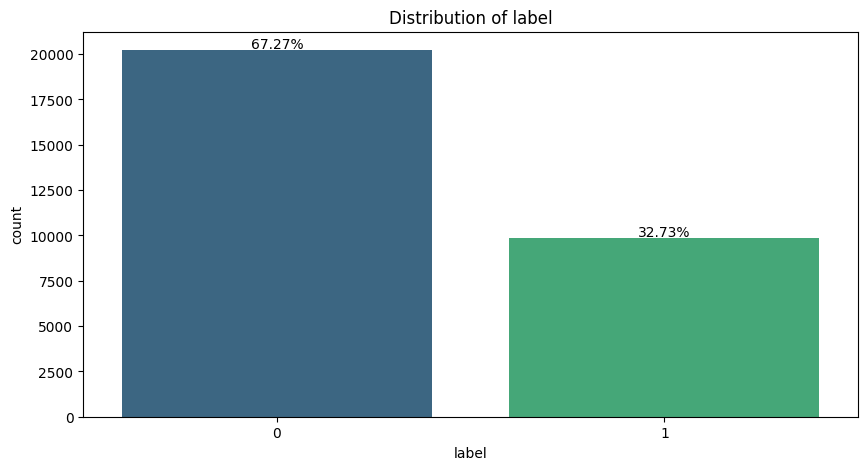

In [30]:
for col in df_raw.columns:
    if col in list_columns_category:
        draw_countplot(col, df_raw)

In [8]:
# Check oulier value for each numerical column
list_col_numerical = []
list_ratio_outlier = []
for col in df_raw.columns:
    if col not in list_columns_category and col not in list_columns_unuse:
        list_col_numerical.append(col)
        print(f'Column: {col}')
        z_score = (df_raw[col] - df_raw[col].mean()) / df_raw[col].std()
        outliers = (z_score.abs() > 3) & (pd.notna(df_raw[col]))
        ratio_outlier = outliers.sum() / len(df_raw)
        list_ratio_outlier.append(ratio_outlier)
        print(f'Number of outliers: {outliers.sum()}')

Column: Age
Number of outliers: 0
Column: PIR
Number of outliers: 0
Column: Weight
Number of outliers: 329
Column: Height
Number of outliers: 36
Column: BMI
Number of outliers: 347
Column: WaistCircumference
Number of outliers: 161
Column: Hba1c
Number of outliers: 671
Column: FastingGlucose
Number of outliers: 652
Column: Albumin
Number of outliers: 302
Column: ALT
Number of outliers: 252
Column: AST
Number of outliers: 213
Column: AlkalinePhosphotase
Number of outliers: 800
Column: BUN
Number of outliers: 409
Column: GGT
Number of outliers: 361
Column: TotalBilirubin
Number of outliers: 405
Column: UricAcid
Number of outliers: 186
Column: Creatinine
Number of outliers: 187
Column: TotalCholesterol
Number of outliers: 200
Column: HDLCholesterol
Number of outliers: 279
Column: Triglycerides
Number of outliers: 323
Column: LDLCholesterol
Number of outliers: 197
Column: Hemoglobin
Number of outliers: 206
Column: Hematocrit
Number of outliers: 145
Column: MeanCellVolumn
Number of outliers

In [9]:
# Check outlier ratio
def draw_outlier_ratio(list_cols, list_ratios):
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(y=list_cols, x=list_ratios, palette='magma')

    for i, rec in enumerate(ax.patches):
        ax.text(
            rec.get_x() + rec.get_width(),
            rec.get_y() + rec.get_height()/2,
            f'{list_ratios[i]*100:.2f}%',
        )
    ax.set_title('Outlier Ratio by Numerical Column')
    ax.set_xlabel('Outlier Ratio')
    ax.set_ylabel('Numerical Columns')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()

C:\Users\iseT1enLoc\AppData\Local\Temp\ipykernel_12836\1271584088.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(y=list_cols, x=list_ratios, palette='magma')


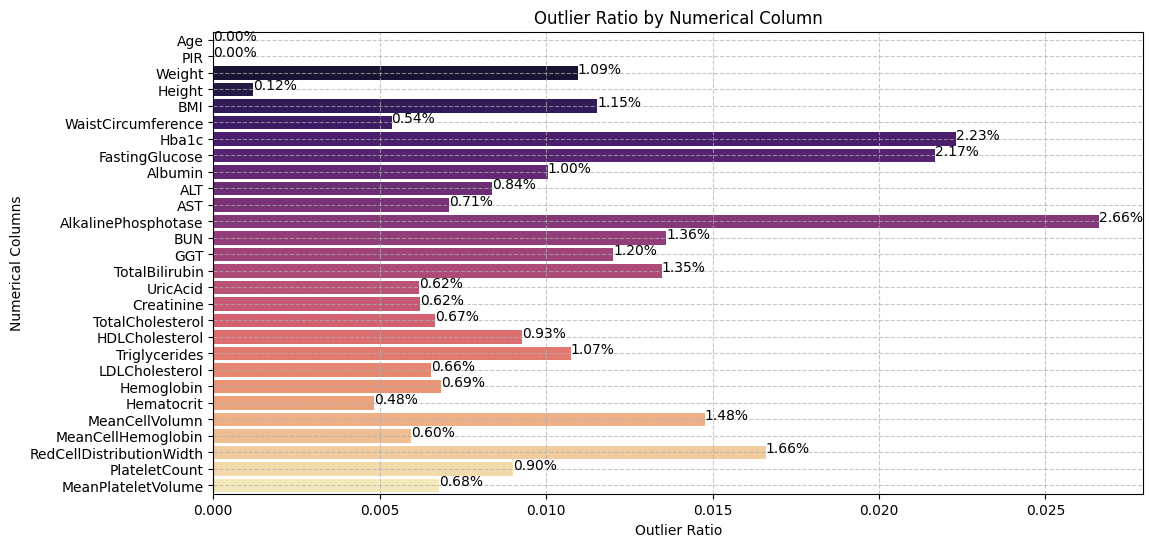

In [10]:
draw_outlier_ratio(list_col_numerical, list_ratio_outlier)